In [1]:
import json
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.notebook import tqdm
from rapidfuzz import fuzz
from rapidfuzz import distance
from src.similarity_matrix import (
    create_sim_m_heatmap,
    create_sim_m,
    create_slices
)

## Load used data

Moving record formats metadata

In [2]:
book_migration_directions = pd.read_csv(
    "outputs/csv/book_migration_direction_info.csv"
)

## Duplicate filtering

In [34]:
jsonls = tuple(
    Path("outputs/json/all_migration_events_parish_splits").glob("*.jsonl")
)
threshold = 0.8

for parish_jsonl in tqdm(jsonls):
    parish_df = pd.read_json(parish_jsonl, lines=True)
    parish_df["duplicate"] = False
    parish_df["is_ap"] = parish_df["book_source"].str.contains("ap")
    p_id = parish_df.loc[0, "parish_id"]

    for (year, direction), group in parish_df.groupby(
        ["year_prediction", "in/out"]
    ):
        events_ap = group[group["is_ap"]]
        events_other = group[~group["is_ap"]]

        other_sizes = (
            events_other.groupby("book_source")
            .size()
            .sort_values(ascending=False)
        )

        source_order = (["__ap__"] if not events_ap.empty else []) + list(
            other_sizes.index
        )

        source_frames = {"__ap__": events_ap}
        source_frames.update(
            {
                src: events_other[events_other["book_source"] == src]
                for src in other_sizes.index
            }
        )

        for i, ref_src in enumerate(source_order[:-1]):
            reference = source_frames[ref_src]
            if reference.empty:
                continue

            for cand_src in source_order[i + 1 :]:
                candidate = source_frames[cand_src]
                if candidate.empty:
                    continue

                sim_m = (
                    create_sim_m(
                        reference["row_data"].to_list(),
                        candidate["row_data"].to_list(),
                        distance.Levenshtein.normalized_similarity,
                        join_char="|",
                        n_workers=-1,
                    )[0]
                    * 100
                )

                duplicates = np.where(sim_m >= threshold)

                duplicate_pages = parish_df.loc[
                    candidate.iloc[duplicates[1]].index, "page_n"
                ].unique()
                parish_df.loc[
                    parish_df["page_n"].isin(duplicate_pages)
                    & (parish_df["book_source"] == cand_src),
                    "duplicate",
                ] = True

    with open(
        f"outputs/json/all_migration_events_parish_splits_duplicate_info/{p_id}_migration_events.jsonl",
        "w",
    ) as fp:
        rows_to_write = []
        for line in parish_df[
            [
                "row_data",
                "row_columns",
                "year_prediction",
                "book_year_start",
                "book_year_end",
                "duplicate",
                "page_n",
                "file_row",
                "in/out",
                "side",
                "parish_id",
                "book_id",
                "print_type",
                "book_source",
                "file_path",
            ]
        ].to_dict(orient="records"):
            rows_to_write.append(json.dumps(line, ensure_ascii=False) + "\n")

        fp.writelines(rows_to_write)

  0%|          | 0/468 [00:00<?, ?it/s]

## Results

In [210]:
def migration_duplicate_filtering_before_after_counts(df, years, in_out_filter:list=None):
    year_mask = df["year_prediction"].isin(range(*years))
    if in_out_filter == None:
        df_years = df[year_mask]
    else:
        df_years = df[year_mask & (df["in/out"].isin(in_out_filter))]

    counts_before = df_years.groupby("book_id").size()
    counts_after = df_years[~df_years["duplicate"]].groupby("book_id").size()

    counts = {}
    for book_id in counts_before.index:
        before = counts_before[book_id]
        after = counts_after.get(book_id, 0)
        counts[book_id] = {
            "before": int(before),
            "after": int(after)
        }

    return counts

In [209]:
def plot_migration_similarity_heatmaps(df, parish, years, in_out_filter:list=None):
    year_mask = df["year_prediction"].isin(range(*years))
    if in_out_filter == None:
        df_years = df[year_mask]
    else:
        df_years = df[year_mask & (df["in/out"].isin(in_out_filter))]
    
    pages = df_years.groupby(["book_id", "page_n"], sort=False)

    page_keys = list(pages.groups.keys())
    page_sort_key = [
        (pages.get_group(k)["year_prediction"].min(), k[1]) for k in page_keys
    ]
    page_keys = [k for _, k in sorted(zip(page_sort_key, page_keys))]

    row_data_per_page = [",".join(pages.get_group(k)["row_data"].sum()) for k in page_keys]
    duplicate_per_page = [pages.get_group(k)["duplicate"].any() for k in page_keys]

    sim_m = create_sim_m(
        row_data_per_page, row_data_per_page,
        fuzz.ratio, join_char="|", n_workers=-1
    )[0]

    sim_m_zeroed = sim_m.copy()
    dup_idx = [i for i, is_dup in enumerate(duplicate_per_page) if is_dup]
    sim_m_zeroed[dup_idx, :] = 0
    sim_m_zeroed[:, dup_idx] = 0

    fig, axs = plt.subplots(1, 3, figsize=(30, 10))
    fig.suptitle(f"{parish}, year range: {years}")

    create_sim_m_heatmap(
        sim_m, xlabel="", ylabel="", ax=axs[0], cbar=False,
        vmin=0, vmax=1,
    )
    axs[0].set_title("No duplicate filtering")

    create_sim_m_heatmap(
        sim_m, xlabel="", ylabel="", ax=axs[1], cbar=False,
        vmin=0, vmax=1, cmap=sns.cm.crest_r
    )
    axs[1].set_title("Duplicate filtering")

    for i, is_dup in enumerate(duplicate_per_page):
        if is_dup:
            axs[1].axhspan(i, i + 1, color="red", alpha=0.3, zorder=2, lw=0)
            axs[1].axvspan(i, i + 1, color="red", alpha=0.3, zorder=2, lw=0)

    create_sim_m_heatmap(
        sim_m_zeroed, xlabel="", ylabel="", ax=axs[2], cbar=False,
        vmin=0, vmax=1
    )
    axs[2].set_title("Duplicate areas zeroed")

    return fig, axs

In [235]:
def plot_book_year_event_heatmap(df, parish, years, in_out_filter:list=None):
    year_mask = df["year_prediction"].isin(range(*years))
    if in_out_filter == None:
        df_years = df[year_mask]
    else:
        df_years = df[year_mask & (df["in/out"].isin(in_out_filter))]

    year_range = list(range(*years))
    book_ids = sorted(df_years["book_id"].unique())

    book_idx = {b: i for i, b in enumerate(book_ids)}
    year_idx = {y: i for i, y in enumerate(year_range)}

    count_matrix = np.full((len(book_ids), len(year_range)), np.nan)
    dup_matrix = np.zeros((len(book_ids), len(year_range)), dtype=bool)

    grouped = df_years.groupby(["book_id", "year_prediction"])
    counts = grouped.size()
    dup_flags = grouped["duplicate"].any()

    for (book_id, year), count in counts.items():
        if year in year_idx:
            count_matrix[book_idx[book_id], year_idx[year]] = count

    for (book_id, year), is_dup in dup_flags.items():
        if year in year_idx and is_dup:
            dup_matrix[book_idx[book_id], year_idx[year]] = True

    fig, ax = plt.subplots(
        figsize=(max(10, len(year_range) * 0.4), max(2, len(book_ids)))
    )
    fig.suptitle(f"{parish}, year range: {years}")

    masked = np.ma.masked_invalid(count_matrix)
    mesh = ax.pcolormesh(masked, cmap="viridis", edgecolors="grey", linewidth=0.5)
    fig.colorbar(mesh, ax=ax, label="Event count")

    for i in range(len(book_ids)):
        for j in range(len(year_range)):
            if dup_matrix[i, j]:
                ax.add_patch(
                    plt.Rectangle(
                        (j, i), 1, 1, fill=False, hatch="////",
                        edgecolor="red", linewidth=1.5
                    )
                )

    ax.set_xticks(np.arange(len(year_range)) + 0.5)
    ax.set_xticklabels(year_range, rotation=90)
    ax.set_yticks(np.arange(len(book_ids)) + 0.5)
    ax.set_yticklabels(book_ids)
    ax.set_xlabel("Year")
    ax.set_ylabel("book_id")
    ax.set_aspect("equal")
    ax.invert_yaxis()

    return fig, ax

{7730: {'before': 2512, 'after': 9}, 41928: {'before': 6004, 'after': 6004}}

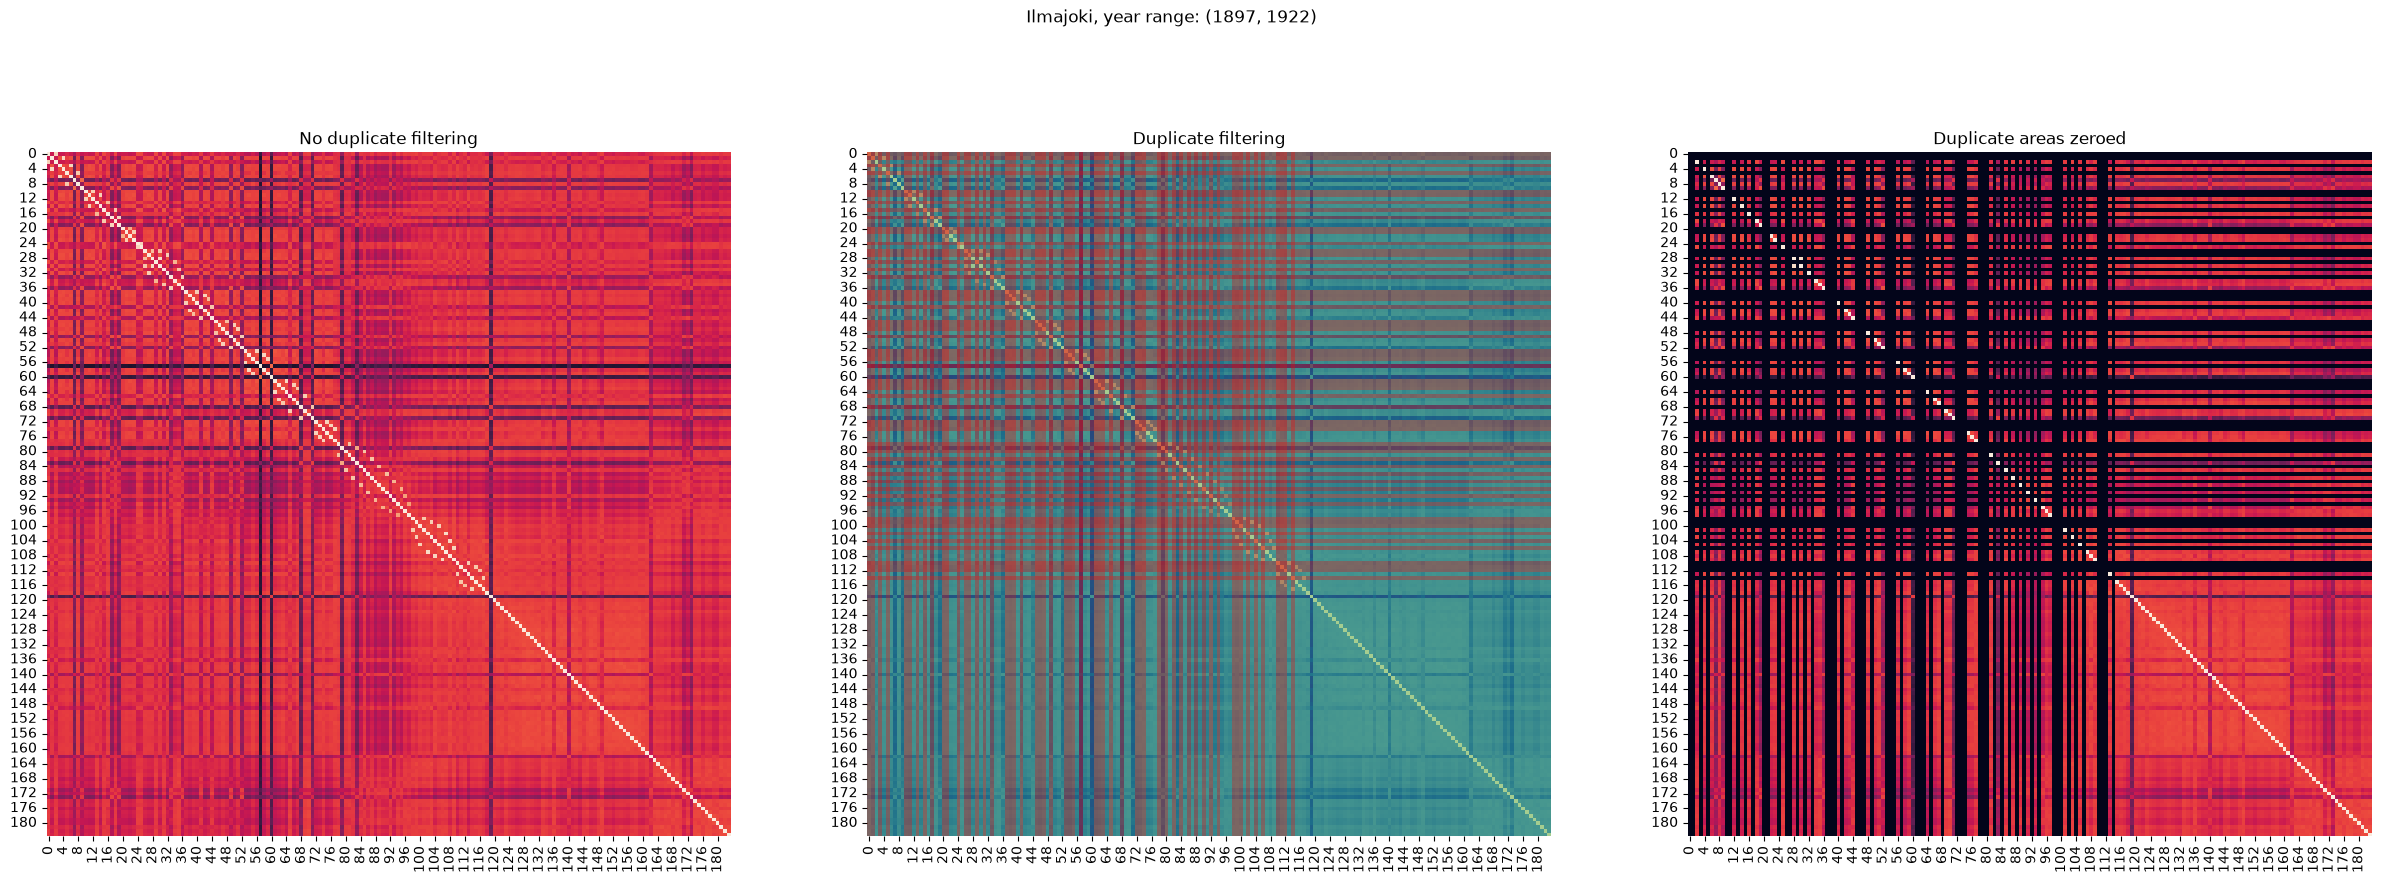

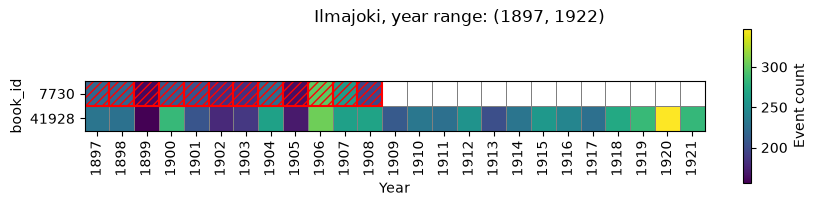

In [236]:
df = pd.read_json(
    f"outputs/json/all_migration_events_parish_splits_duplicate_info/115_migration_events.jsonl",
    lines=True
)
fig, axs = plot_migration_similarity_heatmaps(df, "Ilmajoki", (1897, 1922))
fig, axs = plot_book_year_event_heatmap(df, "Ilmajoki", (1897, 1922))
migration_duplicate_filtering_before_after_counts(df, (1897, 1922))

{16508: {'before': 2388, 'after': 0}, 25359: {'before': 2321, 'after': 2321}}

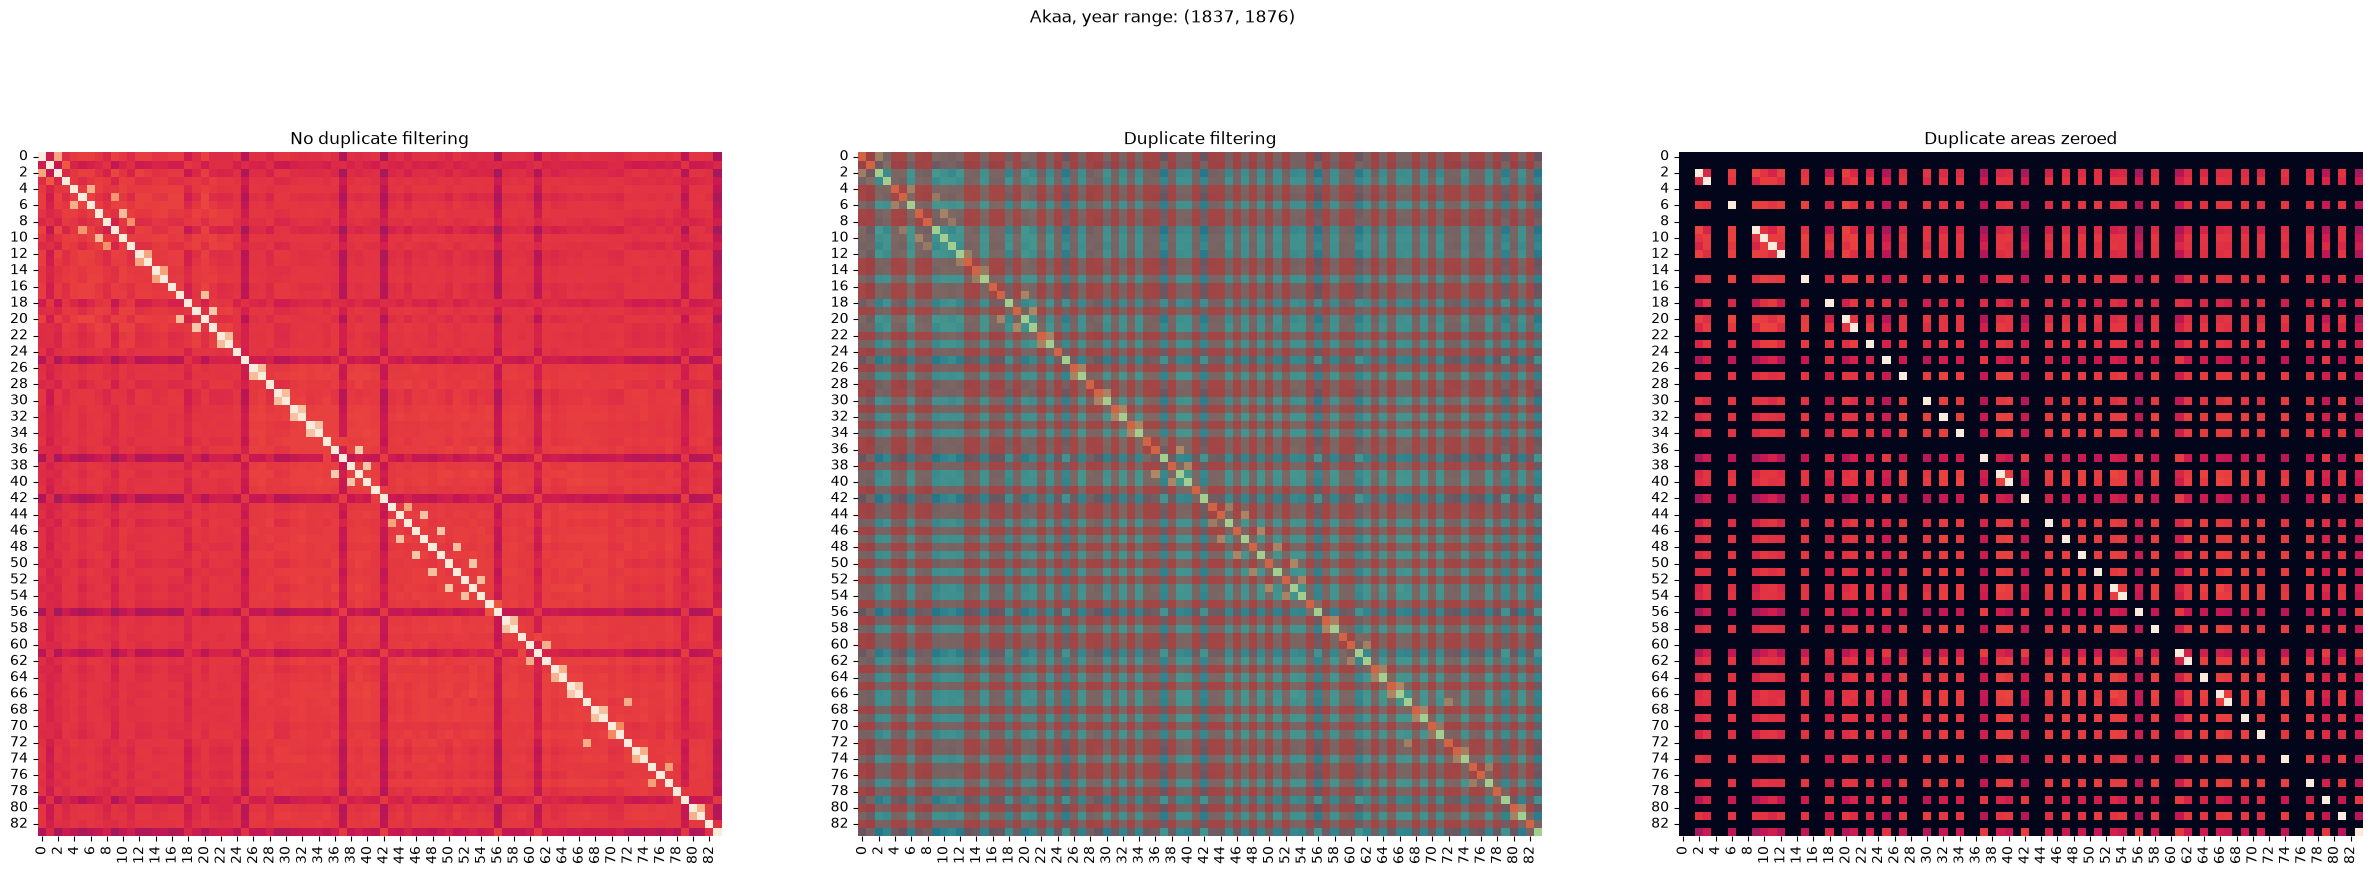

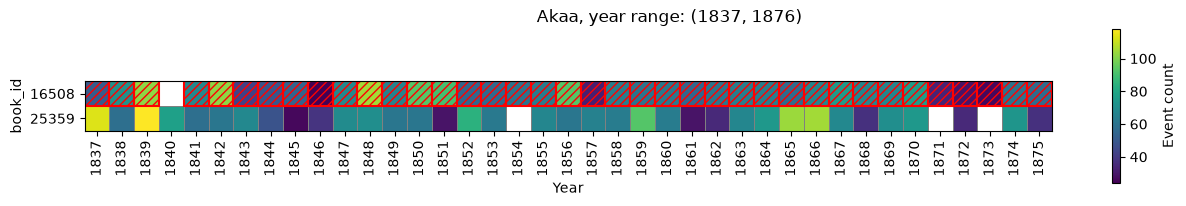

In [ ]:
df = pd.read_json(
    f"outputs/json/all_migration_events_parish_splits_duplicate_info/3_migration_events.jsonl",
    lines=True
)
fig, axs = plot_migration_similarity_heatmaps(df, "Akaa", (1837, 1876))
fig, axs = plot_book_year_event_heatmap(df, "Akaa", (1837, 1876))
migration_duplicate_filtering_before_after_counts(df, (1837, 1876))

{6399: {'before': 374, 'after': 172}, 24794: {'before': 1131, 'after': 1036}}

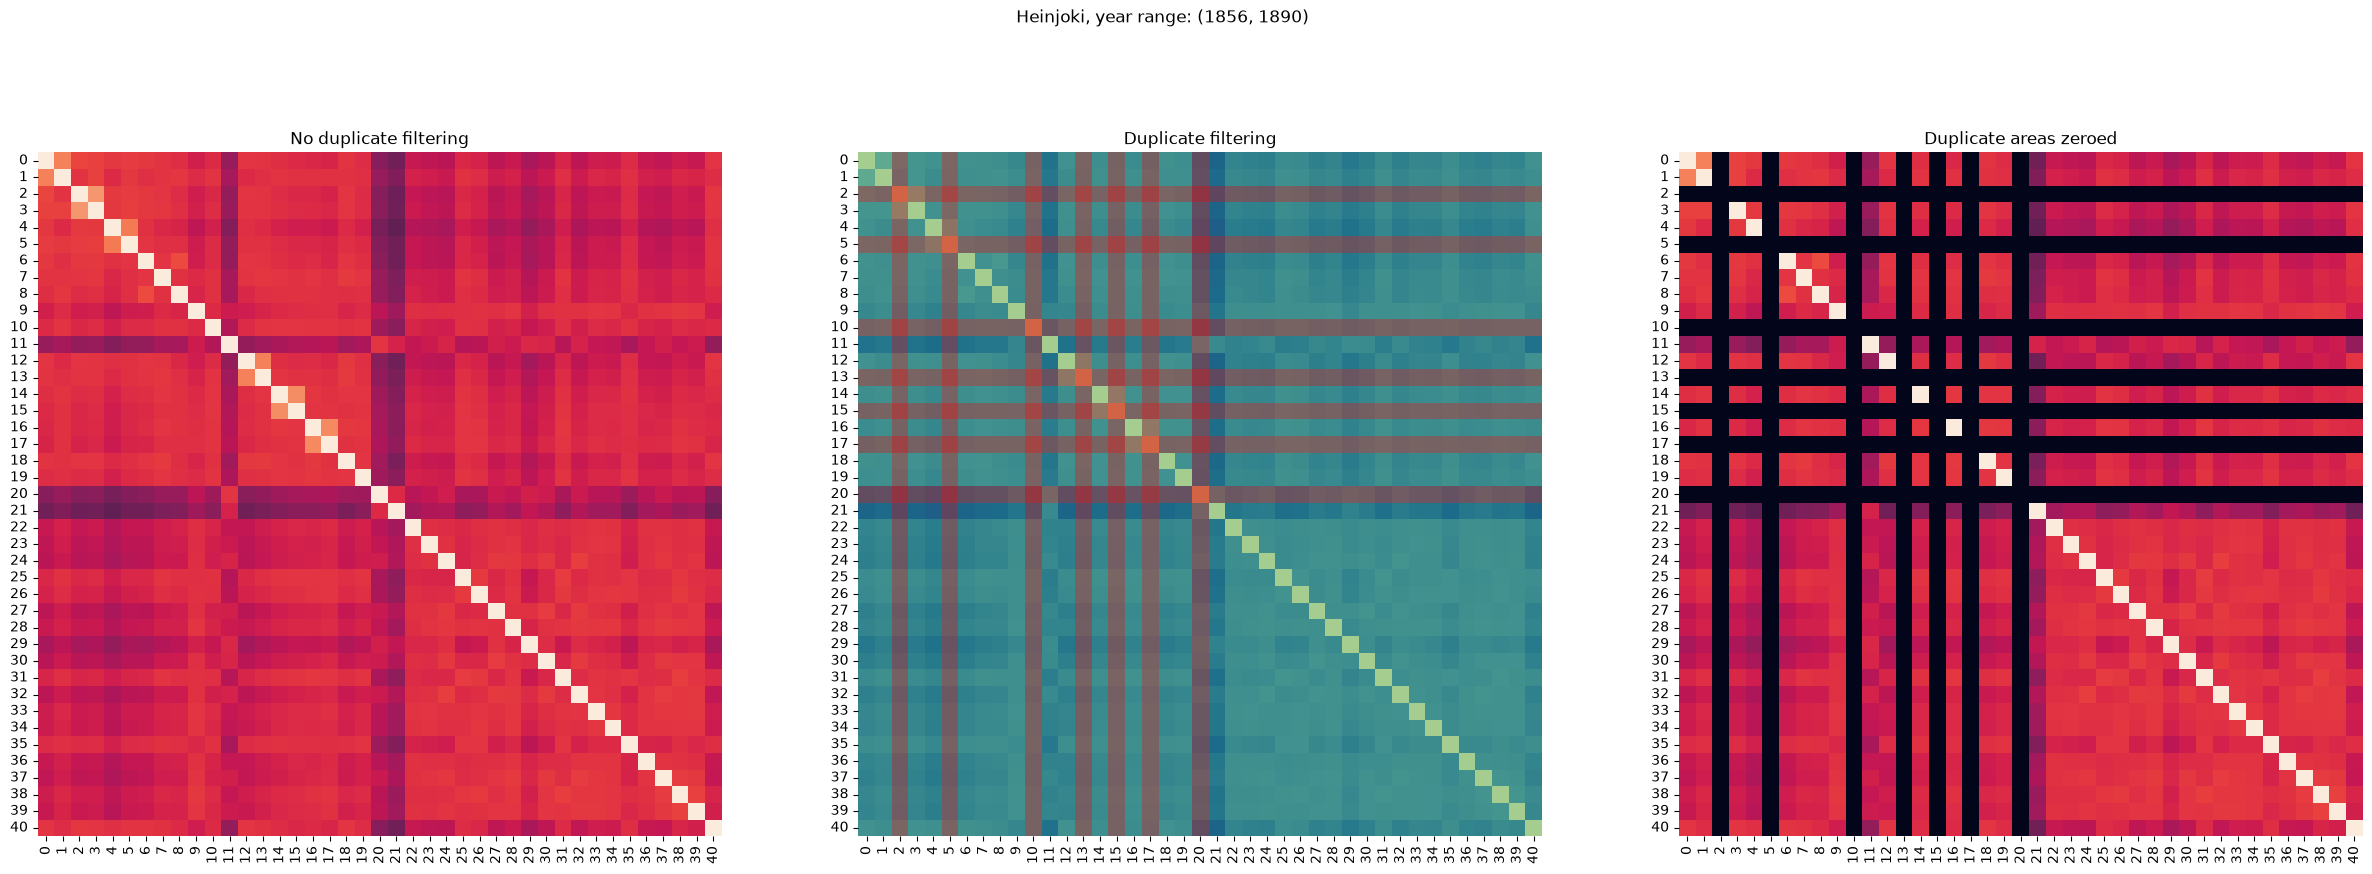

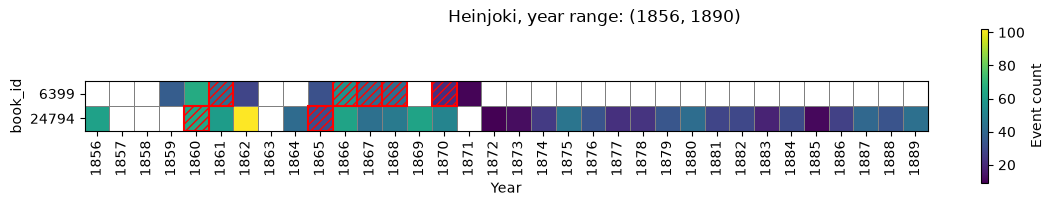

In [221]:
df = pd.read_json(
    f"outputs/json/all_migration_events_parish_splits_duplicate_info/68_migration_events.jsonl",
    lines=True
)

fig, axs = plot_migration_similarity_heatmaps(df, "Heinjoki", (1856, 1890))
fig, axs = plot_book_year_event_heatmap(df, "Heinjoki", (1856, 1890))
migration_duplicate_filtering_before_after_counts(df, (1856, 1890))

{26265: {'before': 298, 'after': 298},
 26266: {'before': 457, 'after': 457},
 26267: {'before': 369, 'after': 369},
 43240: {'before': 1936, 'after': 1936}}

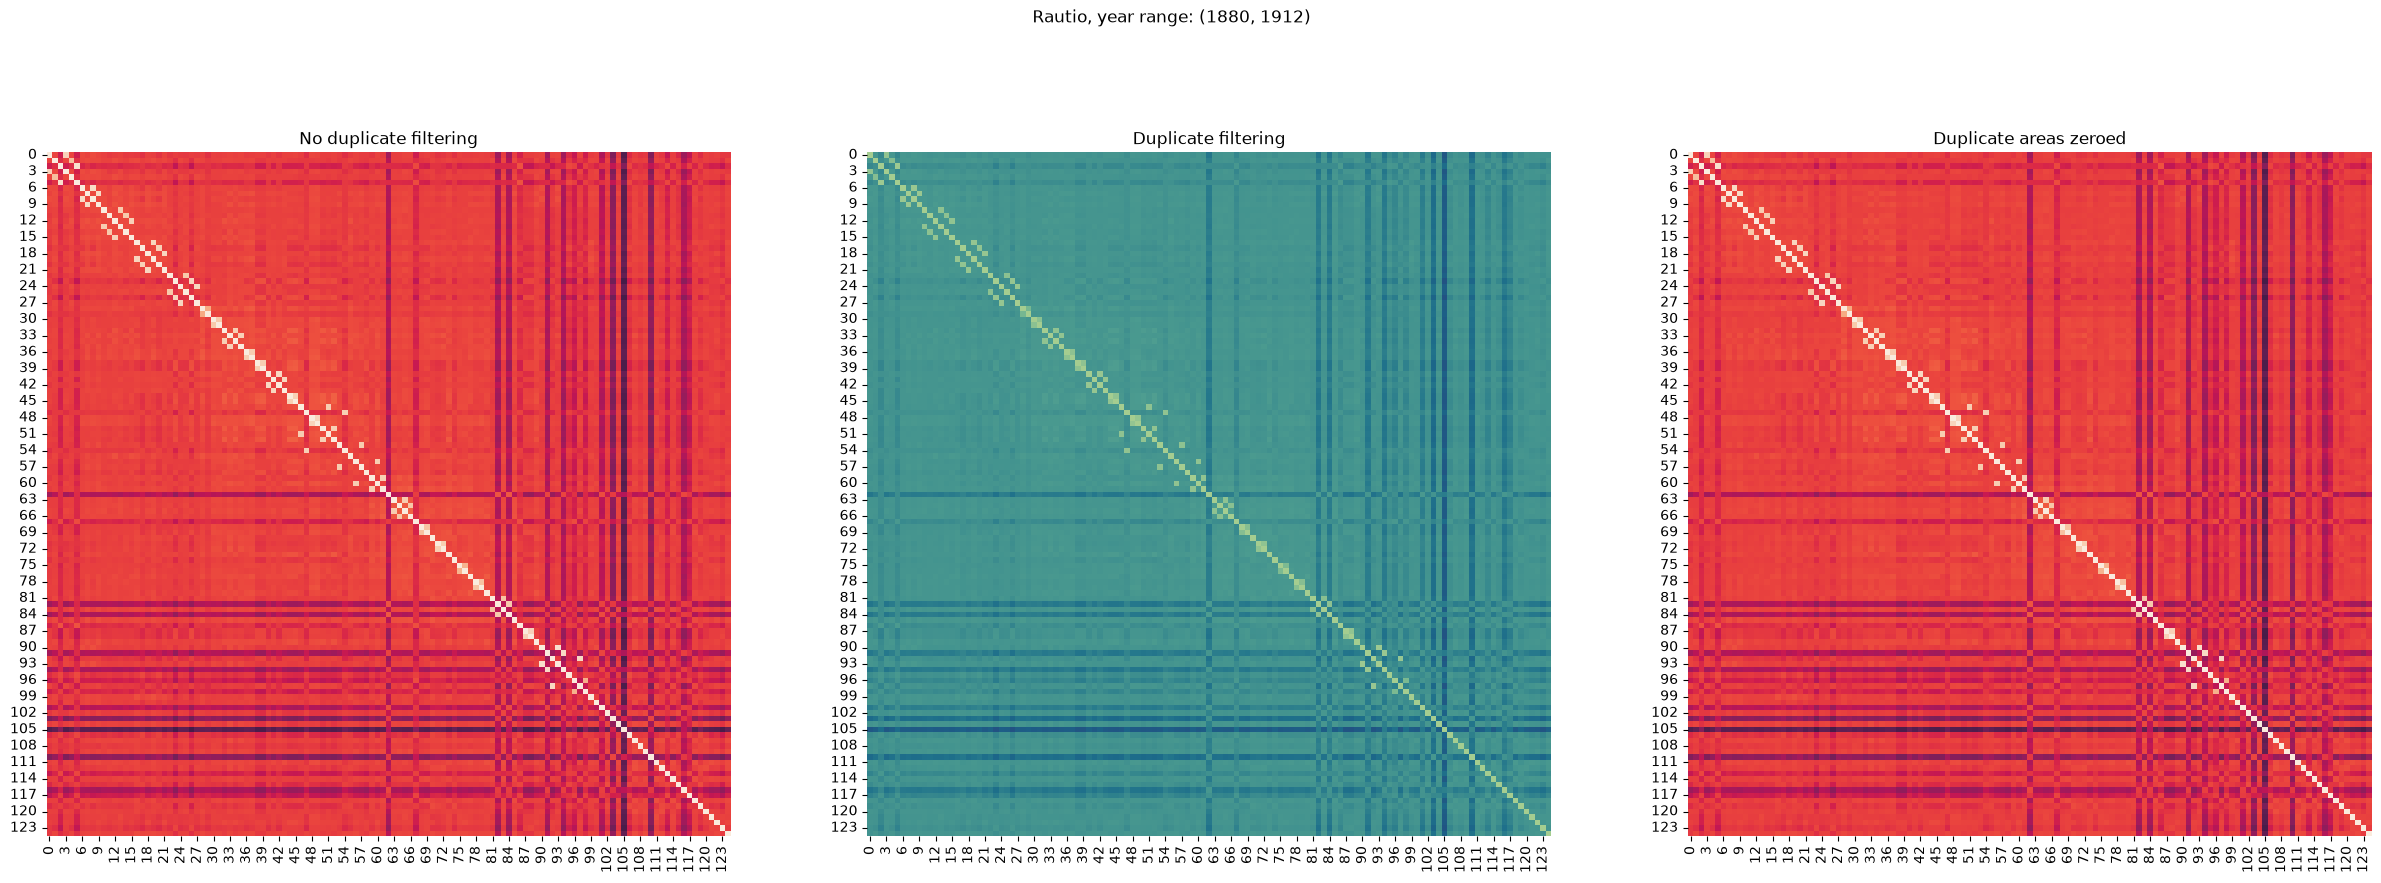

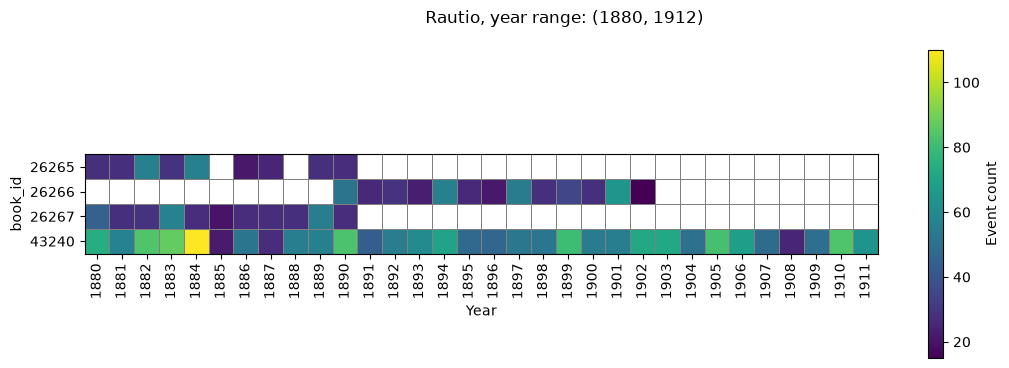

In [232]:
df = pd.read_json(
    f"outputs/json/all_migration_events_parish_splits_duplicate_info/447_migration_events.jsonl",
    lines=True
)
fig, axs = plot_migration_similarity_heatmaps(df, "Rautio", (1880, 1912))
fig, axs = plot_book_year_event_heatmap(df, "Rautio", (1880, 1912))
migration_duplicate_filtering_before_after_counts(df, (1880, 1912))

In [247]:
total_non_duplicate_events = 0
for file_path in Path("outputs/json/all_migration_events_parish_splits_duplicate_info").glob("*.jsonl"):
    with open(file_path, "r") as fp:
        non_duplicate_events = sum(
            1 for line in fp if (
                ("duplicate\": false" in line)
                and (
                    ("in/out\": \"in" in line)
                    or ("in/out\": \"out" in line)
                )
            )
        )
        total_non_duplicate_events += non_duplicate_events

f"Total non-duplicate events with clear direction: {total_non_duplicate_events}"

'Total non-duplicate events with clear direction: 3667767'